<a href="https://colab.research.google.com/github/mustafaberberler/fraud-detection/blob/main/train_lightgbm2222.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LightGBM Hybrid Training — Sparkov Credit Card Fraud Dataset

**Amaç:** AE anomaly score + davranışsal/bağlamsal feature'ları birleştirerek denetimli fraud sınıflandırma.  
**Pipeline:** Autoencoder (1. kademe, denetimsiz) → LightGBM (2. kademe, denetimli, re-ranking)  
**Girdi:** `train_2019_with_ae_scores.csv` (AE notebook çıktısı)  
**Çıktı:** `lgbm_model.pkl`, `lgbm_feature_contract.json`, `training_report.json`

**Deney Tasarımı (Ablation):**
1. LightGBM-Only (AE score olmadan)
2. AE + LightGBM Hybrid (ae_anomaly_score dahil) ← hedef

Bu karşılaştırma tezde hibrit yaklaşımın katkısını kanıtlamak için kritik.

## 0) Environment Setup

In [4]:
!pip install lightgbm optuna shap optuna-integration --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 3.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ---- Paths ----
TRAIN_PATH = "/content/drive/MyDrive/thesis/models/train_2019_with_ae_scores.csv"
VALID_PATH = "/content/drive/MyDrive/thesis/models/valid_2020_with_ae_scores.csv"
TEST_PATH  = "/content/drive/MyDrive/thesis/models/test_final_2020_with_ae_scores.csv"

MODEL_SAVE_DIR = "/content/drive/MyDrive/thesis/models"

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
from optuna_integration import LightGBMPruningCallback

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    average_precision_score
)

np.random.seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1) Feature Contract

LightGBM, AE'den farklı olarak **hem sayısal hem kategorik** feature kullanır.  
Ayrıca `ae_anomaly_score` hybrid bileşen olarak eklenir.

**Leakage kontrolü:** `is_fraud` hedef değişken, feature olarak asla kullanılmaz.  
Risk score'ları (merchant_fraud_rate vb.) varsa dahil etmiyoruz — bunlar label leakage yaratır.

In [6]:
# ---- LightGBM Feature Set ----

# (A) Monetary / Behavioral
NUMERIC_FEATURES = [
    "amt",                 # İşlem tutarı
    "age",                 # Kart sahibi yaşı
    "city_pop",            # Şehir nüfusu
    "geo_distance_km",     # Cardholder-merchant mesafesi (km)
    "geo_distance_log",    # log(1 + mesafe)
    "time_since_last_tx",  # Son işlemden bu yana süre (sn)
    "tx_count_1h",         # Son 1 saatteki işlem sayısı
    "amt_sum_24h",         # Son 24 saatteki toplam harcama
    "amt_mean_hist",       # Tarihsel ortalama tutar
    "amt_vs_mean",         # Mevcut / tarihsel ortalama
]

# (B) Temporal
TEMPORAL_FEATURES = [
    "hour",           # İşlem saati
    "day_of_week",    # Haftanın günü
    "month",          # Ay
    "is_weekend",     # Hafta sonu flag
    "is_night",       # Gece flag
]

# (C) Channel / Context
CHANNEL_FEATURES = [
    "is_online",      # Online işlem flag
    "is_pos",         # POS işlem flag
]

# (D) Categorical (LightGBM native categorical support)
CATEGORICAL_FEATURES = [
    "category",       # İşlem kategorisi (14 unique)
    "gender",         # Cinsiyet
]

# (E) Hybrid — AE'den gelen anomaly score
HYBRID_FEATURES = [
    "ae_anomaly_score",  # Autoencoder reconstruction error
]

# ---- Combined ----
LGBM_FEATURES_BASE = NUMERIC_FEATURES + TEMPORAL_FEATURES + CHANNEL_FEATURES + CATEGORICAL_FEATURES
LGBM_FEATURES_HYBRID = LGBM_FEATURES_BASE + HYBRID_FEATURES

TARGET = "is_fraud"

print(f"Base feature count:   {len(LGBM_FEATURES_BASE)}")
print(f"Hybrid feature count: {len(LGBM_FEATURES_HYBRID)}")
print(f"Categorical:          {CATEGORICAL_FEATURES}")

Base feature count:   19
Hybrid feature count: 20
Categorical:          ['category', 'gender']


## 2) Veri Yükleme & Doğrulama

In [7]:
df_train = pd.read_csv(TRAIN_PATH)
df_valid = pd.read_csv(VALID_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f"Train: {df_train.shape}  | Fraud: {df_train[TARGET].sum():,} ({df_train[TARGET].mean():.4%})")
print(f"Valid: {df_valid.shape}  | Fraud: {df_valid[TARGET].sum():,} ({df_valid[TARGET].mean():.4%})")
print(f"Test:  {df_test.shape}   | Fraud: {df_test[TARGET].sum():,} ({df_test[TARGET].mean():.4%})")

# Feature varlık kontrolü
for name, features in [("Hybrid", LGBM_FEATURES_HYBRID)]:
    missing = [c for c in features if c not in df_train.columns]
    if missing:
        print(f"⚠️ {name} — Eksik: {missing}")
    else:
        print(f"✅ {name} — Tüm feature'lar mevcut.")

Train: (924850, 38)  | Fraud: 5,220 (0.5644%)
Valid: (371825, 38)  | Fraud: 2,286 (0.6148%)
Test:  (555719, 38)   | Fraud: 2,145 (0.3860%)
✅ Hybrid — Tüm feature'lar mevcut.


In [12]:
# Önce NaN doldur — category kolonları geçici olarak object'e al
for df in [df_train, df_valid, df_test]:
    for col in LGBM_FEATURES_HYBRID:
        if df[col].dtype.name == 'category':
            df[col] = df[col].astype(object)
    df[LGBM_FEATURES_HYBRID] = df[LGBM_FEATURES_HYBRID].fillna(0)

# Sonra kategorik kolonları category tipine çevir
for col in CATEGORICAL_FEATURES:
    for df in [df_train, df_valid, df_test]:
        df[col] = df[col].astype('category')

print("✅ Veri hazırlığı tamamlandı.")

✅ Veri hazırlığı tamamlandı.


In [13]:
# ---- Train / Valid / Test split (zaten zaman bazlı yapılmış) ----
# FE'den: Train=2019, Valid=2020 (train kısmı), Test=2020 (test kısmı)
# Bu time-based split drift analizi için de uygun.

X_train = df_train[LGBM_FEATURES_HYBRID]
y_train = df_train[TARGET]

X_valid = df_valid[LGBM_FEATURES_HYBRID]
y_valid = df_valid[TARGET]

X_test = df_test[LGBM_FEATURES_HYBRID]
y_test = df_test[TARGET]

# Class imbalance oranı
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"scale_pos_weight: {scale_pos_weight:.1f} (neg={neg_count:,}, pos={pos_count:,})")
print(f"X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}")

scale_pos_weight: 176.2 (neg=919,630, pos=5,220)
X_train: (924850, 20), X_valid: (371825, 20), X_test: (555719, 20)


## 3) Baseline LightGBM (Optuna HPO olmadan)

Önce baseline model eğitip sonuçları görelim.

In [14]:
baseline_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': 42,
    'n_jobs': -1,
}

dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_FEATURES)
dvalid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=CATEGORICAL_FEATURES, reference=dtrain)

baseline_model = lgb.train(
    baseline_params,
    dtrain,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {baseline_model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.986126	valid's average_precision: 0.952963
[200]	train's average_precision: 0.997556	valid's average_precision: 0.968111
[300]	train's average_precision: 0.999998	valid's average_precision: 0.974476
[400]	train's average_precision: 1	valid's average_precision: 0.976975
[500]	train's average_precision: 1	valid's average_precision: 0.978375
[600]	train's average_precision: 1	valid's average_precision: 0.979128
[700]	train's average_precision: 1	valid's average_precision: 0.979694
[800]	train's average_precision: 1	valid's average_precision: 0.980311
[900]	train's average_precision: 1	valid's average_precision: 0.980679
Early stopping, best iteration is:
[941]	train's average_precision: 1	valid's average_precision: 0.980802

Best iteration: 941


In [15]:
def evaluate_model(model, X, y, set_name=""):
    """Kapsamlı model değerlendirme"""
    y_prob = model.predict(X, num_iteration=model.best_iteration)

    # ROC-AUC
    roc = roc_auc_score(y, y_prob)

    # PR-AUC (primary metric)
    pr = average_precision_score(y, y_prob)

    # Optimal threshold (F1 maximize)
    precisions, recalls, thresholds = precision_recall_curve(y, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_idx]

    # Classification report @ optimal threshold
    y_pred = (y_prob >= best_threshold).astype(int)

    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)

    print(f"{'='*50}")
    print(f"{set_name} Evaluation")
    print(f"{'='*50}")
    print(f"ROC-AUC:          {roc:.4f}")
    print(f"PR-AUC (AP):      {pr:.4f}  ← primary metric")
    print(f"Best F1:          {best_f1:.4f}  (threshold={best_threshold:.4f})")
    print(f"Precision:        {prec:.4f}")
    print(f"Recall:           {rec:.4f}")

    cm = confusion_matrix(y, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  TN={cm[0,0]:>8,}  FP={cm[0,1]:>6,}")
    print(f"  FN={cm[1,0]:>8,}  TP={cm[1,1]:>6,}")

    return {
        'roc_auc': roc, 'pr_auc': pr, 'f1': best_f1,
        'precision': prec, 'recall': rec,
        'threshold': best_threshold, 'y_prob': y_prob
    }

baseline_results_valid = evaluate_model(baseline_model, X_valid, y_valid, "Baseline — Valid")
baseline_results_test  = evaluate_model(baseline_model, X_test,  y_test,  "Baseline — Test")

Baseline — Valid Evaluation
ROC-AUC:          0.9995
PR-AUC (AP):      0.9808  ← primary metric
Best F1:          0.9440  (threshold=0.8830)
Precision:        0.9678
Recall:           0.9213

Confusion Matrix:
  TN= 369,469  FP=    70
  FN=     180  TP= 2,106
Baseline — Test Evaluation
ROC-AUC:          0.9986
PR-AUC (AP):      0.9594  ← primary metric
Best F1:          0.9239  (threshold=0.7796)
Precision:        0.9520
Recall:           0.8974

Confusion Matrix:
  TN= 553,477  FP=    97
  FN=     220  TP= 1,925


## 4) Optuna Hyperparameter Optimization

PR-AUC'yi optimize ediyoruz (fraud detection'da ROC-AUC'den daha güvenilir).

In [19]:
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'scale_pos_weight': scale_pos_weight,
        'verbose': -1,
        'seed': 42,
        'n_jobs': -1,
        'feature_pre_filter': False, # Add this line to resolve the LightGBMError

        # Optuna search space
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    # Dataset'leri her trial'da burada oluştur
    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dvalid],
        valid_names=['valid'],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            LightGBMPruningCallback(trial, 'average_precision', valid_name='valid')
        ]
    )

    y_prob = model.predict(X_valid, num_iteration=model.best_iteration)
    return average_precision_score(y_valid, y_prob)

# Optuna study
N_TRIALS = 50  # Colab'da ~30-60 dk sürer, azaltabilirsiniz

study = optuna.create_study(direction='maximize', study_name='lgbm_fraud_detection')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best PR-AUC: 0.9754
Best params: {'learning_rate': 0.042105375823282845, 'num_leaves': 117, 'max_depth': 6, 'min_child_samples': 65, 'feature_fraction': 0.6777363458830614, 'bagging_fraction': 0.5475293432366644, 'bagging_freq': 9, 'reg_alpha': 3.0236457372797686e-08, 'reg_lambda': 0.00030878507206382225, 'min_split_gain': 0.46792921992091274}


In [20]:
# En iyi parametrelerle final model eğit
best_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'seed': 42,
    'n_jobs': -1,
    **study.best_params
}

best_model = lgb.train(
    best_params,
    dtrain,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {best_model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.951147	valid's average_precision: 0.94467
[200]	train's average_precision: 0.982682	valid's average_precision: 0.964294
[300]	train's average_precision: 0.99261	valid's average_precision: 0.971589
[400]	train's average_precision: 0.996576	valid's average_precision: 0.97342
[500]	train's average_precision: 0.998217	valid's average_precision: 0.973892
[600]	train's average_precision: 0.999159	valid's average_precision: 0.974805
[700]	train's average_precision: 0.999599	valid's average_precision: 0.97547
[800]	train's average_precision: 0.999859	valid's average_precision: 0.976716
[900]	train's average_precision: 0.999975	valid's average_precision: 0.977325
[1000]	train's average_precision: 1	valid's average_precision: 0.977904
Did not meet early stopping. Best iteration is:
[1000]	train's average_precision: 1	valid's average_precision: 0.977904

Best iteration: 1000


In [21]:
# Optimized model evaluation
opt_results_valid = evaluate_model(best_model, X_valid, y_valid, "Optimized — Valid")
opt_results_test  = evaluate_model(best_model, X_test,  y_test,  "Optimized — Test")

Optimized — Valid Evaluation
ROC-AUC:          0.9996
PR-AUC (AP):      0.9779  ← primary metric
Best F1:          0.9403  (threshold=0.8819)
Precision:        0.9586
Recall:           0.9226

Confusion Matrix:
  TN= 369,448  FP=    91
  FN=     177  TP= 2,109
Optimized — Test Evaluation
ROC-AUC:          0.9986
PR-AUC (AP):      0.9565  ← primary metric
Best F1:          0.9188  (threshold=0.8988)
Precision:        0.9448
Recall:           0.8942

Confusion Matrix:
  TN= 553,462  FP=   112
  FN=     227  TP= 1,918


## 5) Ablation Study: Hybrid vs LightGBM-Only

AE anomaly score'un katkısını ölçmek için aynı modeli `ae_anomaly_score` olmadan eğit.

In [22]:
# LightGBM-Only (AE score olmadan)
X_train_base = df_train[LGBM_FEATURES_BASE]
X_valid_base = df_valid[LGBM_FEATURES_BASE]
X_test_base  = df_test[LGBM_FEATURES_BASE]

dtrain_base = lgb.Dataset(X_train_base, label=y_train, categorical_feature=CATEGORICAL_FEATURES)
dvalid_base = lgb.Dataset(X_valid_base, label=y_valid, categorical_feature=CATEGORICAL_FEATURES, reference=dtrain_base)

base_model = lgb.train(
    best_params,  # Aynı HPO parametreleri
    dtrain_base,
    valid_sets=[dtrain_base, dvalid_base],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

base_only_valid = evaluate_model(base_model, X_valid_base, y_valid, "LightGBM-Only — Valid")
base_only_test  = evaluate_model(base_model, X_test_base,  y_test,  "LightGBM-Only — Test")

Training until validation scores don't improve for 50 rounds
[100]	train's average_precision: 0.959912	valid's average_precision: 0.948963
[200]	train's average_precision: 0.983635	valid's average_precision: 0.965208
[300]	train's average_precision: 0.993175	valid's average_precision: 0.972435
[400]	train's average_precision: 0.996386	valid's average_precision: 0.973727
[500]	train's average_precision: 0.998276	valid's average_precision: 0.975319
[600]	train's average_precision: 0.999389	valid's average_precision: 0.976747
Early stopping, best iteration is:
[643]	train's average_precision: 0.999587	valid's average_precision: 0.976997
LightGBM-Only — Valid Evaluation
ROC-AUC:          0.9997
PR-AUC (AP):      0.9770  ← primary metric
Best F1:          0.9316  (threshold=0.9368)
Precision:        0.9496
Recall:           0.9143

Confusion Matrix:
  TN= 369,428  FP=   111
  FN=     196  TP= 2,090
LightGBM-Only — Test Evaluation
ROC-AUC:          0.9985
PR-AUC (AP):      0.9530  ← primary 

In [23]:
# Karşılaştırma tablosu
print("\n" + "="*65)
print("ABLATION STUDY — Test Set Karşılaştırması")
print("="*65)
print(f"{'Metric':<20} {'LightGBM-Only':>15} {'Hybrid (AE+LGBM)':>18} {'Delta':>10}")
print("-"*65)

for metric in ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']:
    base_val = base_only_test[metric]
    hybrid_val = opt_results_test[metric]
    delta = hybrid_val - base_val
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"{metric:<20} {base_val:>15.4f} {hybrid_val:>18.4f} {delta:>+9.4f} {arrow}")

print("="*65)


ABLATION STUDY — Test Set Karşılaştırması
Metric                 LightGBM-Only   Hybrid (AE+LGBM)      Delta
-----------------------------------------------------------------
roc_auc                       0.9985             0.9986   +0.0001 ↑
pr_auc                        0.9530             0.9565   +0.0036 ↑
f1                            0.9042             0.9188   +0.0146 ↑
precision                     0.9224             0.9448   +0.0224 ↑
recall                        0.8867             0.8942   +0.0075 ↑


## 6) Feature Importance & SHAP

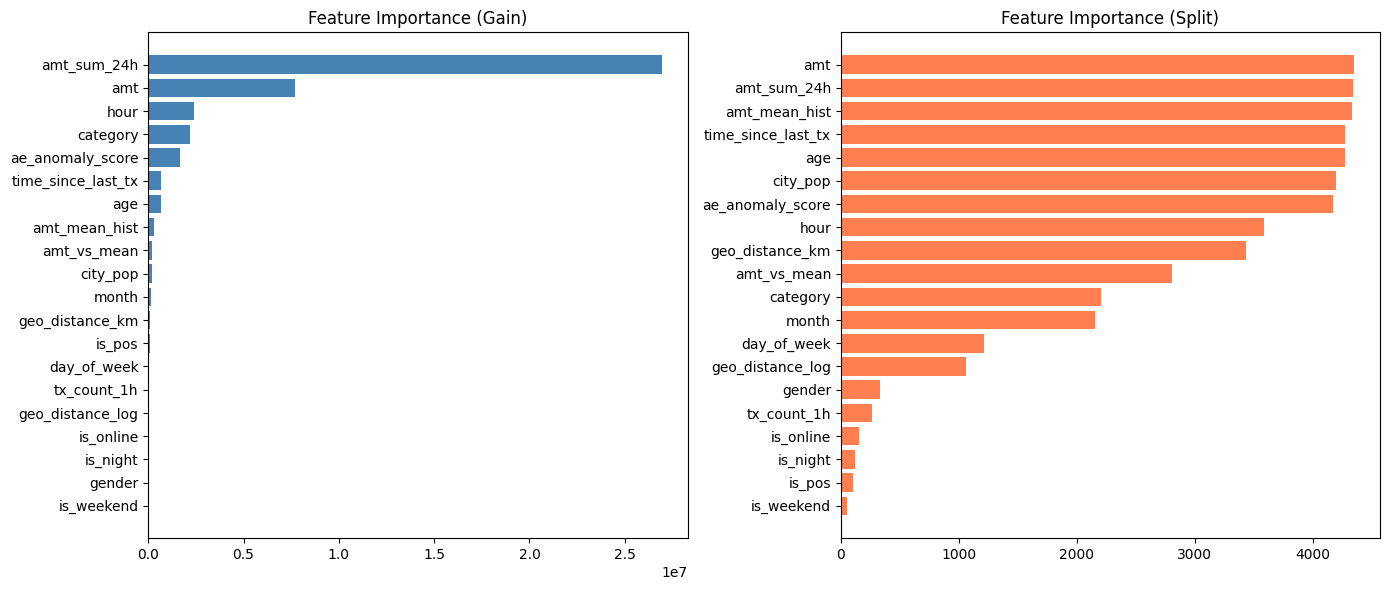


Top 10 by Gain:
           feature  importance_gain
       amt_sum_24h     2.694275e+07
               amt     7.718129e+06
              hour     2.396672e+06
          category     2.166698e+06
  ae_anomaly_score     1.659794e+06
time_since_last_tx     6.907970e+05
               age     6.634965e+05
     amt_mean_hist     2.891601e+05
       amt_vs_mean     1.847211e+05
          city_pop     1.723577e+05


In [24]:
# LightGBM native feature importance
importance_df = pd.DataFrame({
    'feature': best_model.feature_name(),
    'importance_gain': best_model.feature_importance(importance_type='gain'),
    'importance_split': best_model.feature_importance(importance_type='split')
}).sort_values('importance_gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gain
axes[0].barh(importance_df['feature'], importance_df['importance_gain'], color='steelblue')
axes[0].set_title('Feature Importance (Gain)')
axes[0].invert_yaxis()

# Split
imp_split = importance_df.sort_values('importance_split', ascending=False)
axes[1].barh(imp_split['feature'], imp_split['importance_split'], color='coral')
axes[1].set_title('Feature Importance (Split)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 10 by Gain:")
print(importance_df[['feature', 'importance_gain']].head(10).to_string(index=False))

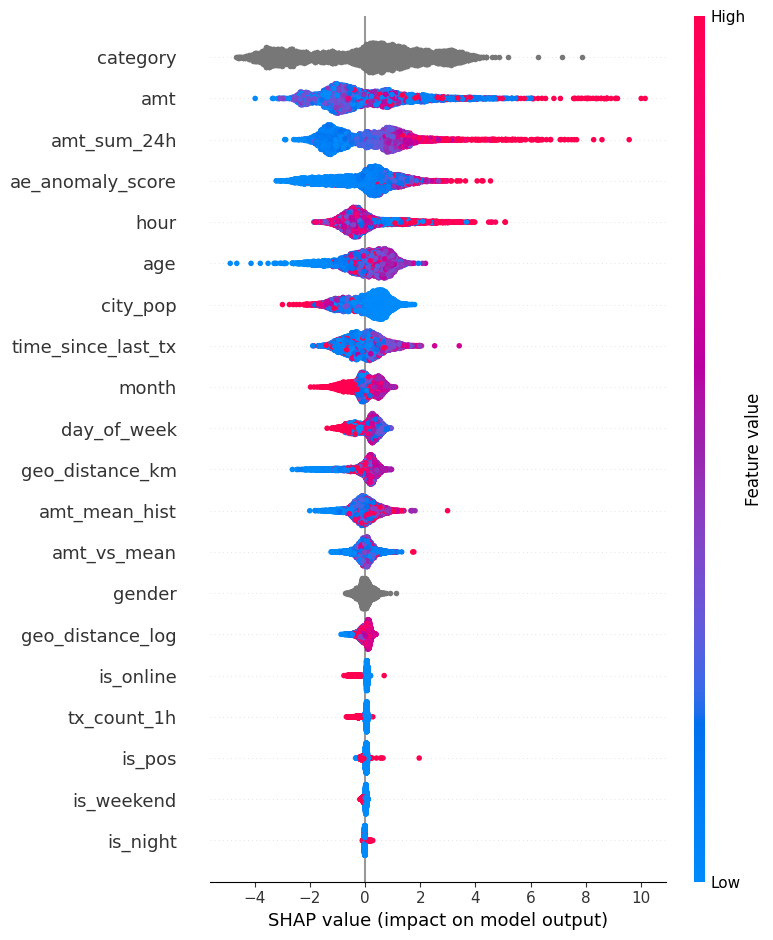

In [25]:
# SHAP analizi (TreeSHAP — LightGBM ile çok hızlı)
import shap

# Sample üzerinden hesapla (full set çok yavaş olabilir)
SHAP_SAMPLE = 5000
shap_idx = np.random.choice(len(X_test), SHAP_SAMPLE, replace=False)
X_shap = X_test.iloc[shap_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# SHAP summary plot
shap.summary_plot(shap_values, X_shap, show=True)

## 7) PR Curve & Threshold Analysis

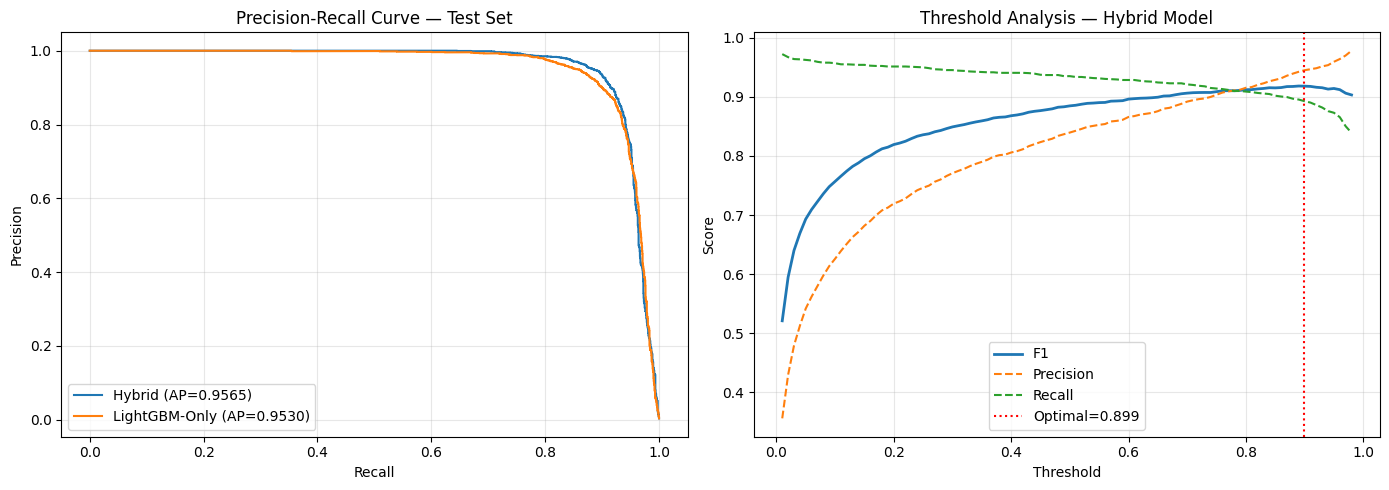

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve — Hybrid vs Base
for label, results in [('Hybrid', opt_results_test), ('LightGBM-Only', base_only_test)]:
    prec, rec, _ = precision_recall_curve(y_test, results['y_prob'])
    ap = average_precision_score(y_test, results['y_prob'])
    axes[0].plot(rec, prec, label=f'{label} (AP={ap:.4f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve — Test Set')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Threshold vs F1/Precision/Recall
y_prob_test = opt_results_test['y_prob']
thresholds_range = np.arange(0.01, 0.99, 0.01)
f1s, precs, recs = [], [], []

for t in thresholds_range:
    y_pred_t = (y_prob_test >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

axes[1].plot(thresholds_range, f1s, label='F1', linewidth=2)
axes[1].plot(thresholds_range, precs, label='Precision', linestyle='--')
axes[1].plot(thresholds_range, recs, label='Recall', linestyle='--')
axes[1].axvline(opt_results_test['threshold'], color='red', linestyle=':', label=f"Optimal={opt_results_test['threshold']:.3f}")
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Threshold Analysis — Hybrid Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8) Model & Artefact Kaydetme

In [27]:
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Model
model_path = os.path.join(MODEL_SAVE_DIR, "lgbm_model.pkl")
joblib.dump(best_model, model_path)
print(f"✅ Model saved: {model_path}")

# Feature contract
feature_contract = {
    "lgbm_features_hybrid": LGBM_FEATURES_HYBRID,
    "lgbm_features_base": LGBM_FEATURES_BASE,
    "categorical_features": CATEGORICAL_FEATURES,
    "hybrid_features": HYBRID_FEATURES,
    "target": TARGET,
    "best_params": best_params,
    "best_iteration": best_model.best_iteration,
    "optimal_threshold": float(opt_results_test['threshold']),
    "dataset": "sparkov_credit_card_fraud"
}

contract_path = os.path.join(MODEL_SAVE_DIR, "lgbm_feature_contract.json")
with open(contract_path, 'w') as f:
    json.dump(feature_contract, f, indent=2, default=str)
print(f"✅ Feature contract saved: {contract_path}")

# Training report
training_report = {
    "dataset": "sparkov_credit_card_fraud",
    "train_size": len(df_train),
    "valid_size": len(df_valid),
    "test_size": len(df_test),
    "fraud_rate_train": float(df_train[TARGET].mean()),
    "optuna_trials": N_TRIALS,
    "best_iteration": best_model.best_iteration,
    "results": {
        "hybrid_test": {k: float(v) for k, v in opt_results_test.items() if k != 'y_prob'},
        "base_only_test": {k: float(v) for k, v in base_only_test.items() if k != 'y_prob'},
        "hybrid_valid": {k: float(v) for k, v in opt_results_valid.items() if k != 'y_prob'},
    },
    "ablation": {
        "ae_contribution_pr_auc": float(opt_results_test['pr_auc'] - base_only_test['pr_auc']),
        "ae_contribution_roc_auc": float(opt_results_test['roc_auc'] - base_only_test['roc_auc']),
    }
}

report_path = os.path.join(MODEL_SAVE_DIR, "training_report.json")
with open(report_path, 'w') as f:
    json.dump(training_report, f, indent=2)
print(f"✅ Training report saved: {report_path}")

✅ Model saved: /content/drive/MyDrive/thesis/models/lgbm_model.pkl
✅ Feature contract saved: /content/drive/MyDrive/thesis/models/lgbm_feature_contract.json
✅ Training report saved: /content/drive/MyDrive/thesis/models/training_report.json


## Özet

**Üretilen artefaktlar:**
- `lgbm_model.pkl` — Eğitilmiş LightGBM modeli (Optuna ile optimize edilmiş)
- `lgbm_feature_contract.json` — Feature listesi, parametreler, optimal threshold
- `training_report.json` — Tüm metrikler, ablation sonuçları

**Sonraki adımlar:**
1. XAI katmanı (TreeSHAP detaylı, DiCE/NICE counterfactual)
2. Drift monitoring (PSI/KL divergence)
3. Neo4j graph analytics entegrasyonu
4. Kafka streaming pipeline entegrasyonu
5. End-to-end system integration + dashboard